In [35]:
## Multimodal agent

## Research Agent

### Create an agent that performs research using the TavilySearch tool. This agent is used to gather the required information.

## Chart Generator Agent
### Create an agent that generates charts using the PythonREPL tool. This agent is used to create charts.

## Multi-Agent Graph

In [1]:
# =========================
# Imports & Setup
# =========================
import operator
import uuid
import os
from typing import Annotated, Sequence
from typing_extensions import TypedDict

from dotenv import load_dotenv
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.runnables import RunnableConfig
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import create_react_agent
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.checkpoint.memory import MemorySaver
from langchain_experimental.utilities import PythonREPL

C:\Users\E264598\AppData\Local\Temp\ipykernel_18528\4208707233.py:13: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults
C:\Users\E264598\AppData\Local\Temp\ipykernel_18528\4208707233.py:19: DeprecationWarning: `langchain-experimental` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-experimental/issues/87 for details.
  from langchain_experimental.utilities import PythonREPL


In [4]:


load_dotenv(override=True)

# =========================
# Python REPL Tool
# =========================
python_repl = PythonREPL()

## Tavily Search Tool
# Tavily search tool
tavily_tool = TavilySearchResults(
    max_results=3,
    search_depth="advanced"
)

@tool
def python_repl_tool(
    code: Annotated[str, "Pure python code only. You MUST save charts as image files."]
):
    """
    Executes Python code. Charts MUST be saved to disk and file path printed.
    """
    try:
        result = python_repl.run(code)
    except BaseException as e:
        return f"Execution failed: {repr(e)}"

    return f"Python executed successfully.\n{result}"

# =========================
# LLM Setup (Groq)
# =========================
llm = ChatOpenAI(
    #model="meta-llama/llama-4-scout-17b-16e-instruct",
    model="qwen/qwen3-32b",
    base_url="https://api.groq.com/openai/v1",
    api_key=os.getenv("GROQ_API_KEY"),
    temperature=0
)

# =========================
# System Prompt Helper
# =========================
def make_system_prompt(suffix: str) -> str:
    return (
        "You are part of a multi-agent system.\n"
        "Follow your role strictly.\n"
        "Do not refuse tasks.\n"
        "Do not explain limitations.\n"
        f"{suffix}"
    )

# =========================
# Research Agent (FORCED DATA)
# =========================
research_agent_system_prompt = """
You are a research agent.

Your job is to gather data needed for chart generation.

STRICT RULES:
1. Use tools like TavilySearch when external data is required.
2. ALWAYS extract or infer numeric values.
3. NEVER refuse due to lack of real-time access.
4. If exact values are unavailable, use best estimates.
5. DO NOT generate charts or code.

OUTPUT FORMAT (MANDATORY):
Return data in a simple, structured, machine-readable format.

Example:
Label: <category or x-axis value>
Value: <numeric value>
Unit: <optional>

Repeat for each data point.
"""

C:\Users\E264598\AppData\Local\Temp\ipykernel_30088\3182768948.py:10: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_tool = TavilySearchResults(


In [5]:
research_agent = create_react_agent(
    llm,
    tools=[tavily_tool],
    prompt=make_system_prompt(research_agent_system_prompt),
)

def research_node(state: MessagesState) -> MessagesState:
    result = research_agent.invoke(state)
    return {"messages": result["messages"]}

C:\Users\E264598\AppData\Local\Temp\ipykernel_30088\2488574887.py:1: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  research_agent = create_react_agent(


In [6]:
# =========================
# Chart Agent (FORCED PYTHONREPL)
# =========================
chart_generator_system_prompt = """
You are a chart-generation agent.

Your job is to generate charts based on structured numeric data
provided by the research agent.

STRICT RULES:
1. You MUST parse numeric values from the previous message.
2. You MUST decide an appropriate chart type (bar, line, pie) unless specified.
3. You MUST use the `python_repl_tool` to execute your code. DO NOT output raw python code in markdown. Use the tool.
4. You MUST save the chart as a PNG file.
5. You MUST print the saved file path.
6. You MUST NOT refuse or explain limitations.
7. You MUST NOT return FINAL ANSWER until AFTER the tool executes.
8. ALWAYS CALL THE TOOL with proper JSON/tool call format. NEVER write Python code without calling the tool.

Charting rules:
- Use matplotlib
- Label axes clearly
- Add a meaningful title
- Use plt.savefig(), NOT plt.show()

After successful execution, respond ONLY with:
FINAL ANSWER
"""


chart_agent = create_react_agent(
    llm,
    tools=[python_repl_tool],
    prompt=make_system_prompt(chart_generator_system_prompt),
)

def chart_node(state: MessagesState) -> MessagesState:
    result = chart_agent.invoke(state)
    return {"messages": result["messages"]}

C:\Users\E264598\AppData\Local\Temp\ipykernel_30088\1432426395.py:31: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  chart_agent = create_react_agent(


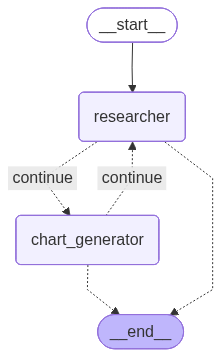

In [7]:


# =========================
# Router
# =========================
def router(state: MessagesState):
    last_message = state["messages"][-1]
    if "FINAL ANSWER" in last_message.content:
        return END
    return "continue"

# =========================
# Build LangGraph
# =========================
workflow = StateGraph(MessagesState)
workflow.add_node("researcher", research_node)
workflow.add_node("chart_generator", chart_node)

workflow.add_conditional_edges(
    "researcher",
    router,
    {"continue": "chart_generator", END: END},
)
workflow.add_conditional_edges(
    "chart_generator",
    router,
    {"continue": "researcher", END: END},
)

workflow.add_edge(START, "researcher")

app = workflow.compile(checkpointer=MemorySaver())

app



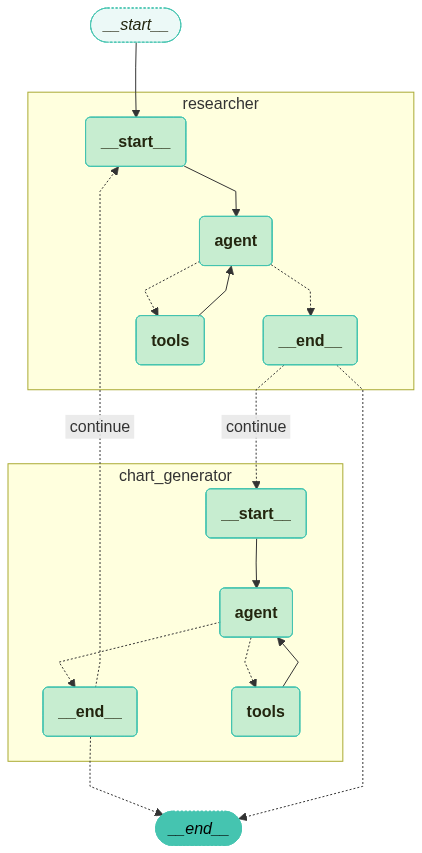

In [9]:
from langchain_opentutorial.graphs import visualize_graph
visualize_graph(app, xray=True)

Python REPL can execute arbitrary code. Use with caution.


{'messages': [HumanMessage(content='do a reserach on gdps of india, usa, and china for the year 2025 & then compare them using a bar chart', additional_kwargs={}, response_metadata={}, id='793f0aac-1f9d-4d7e-83b6-3e2a33df7002'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 374, 'prompt_tokens': 365, 'total_tokens': 739, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 334, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': None, 'queue_time': 0.053362595, 'prompt_time': 0.015689505, 'completion_time': 1.341775036, 'total_time': 1.3574645410000001}, 'model_provider': 'openai', 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_5cf921caa2', 'id': 'chatcmpl-798d91cb-d28f-46b6-8029-503a8b392a09', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e5cdb-4d1f-7aa0-af84-77019e14d78d-0', tool_calls=[{'nam

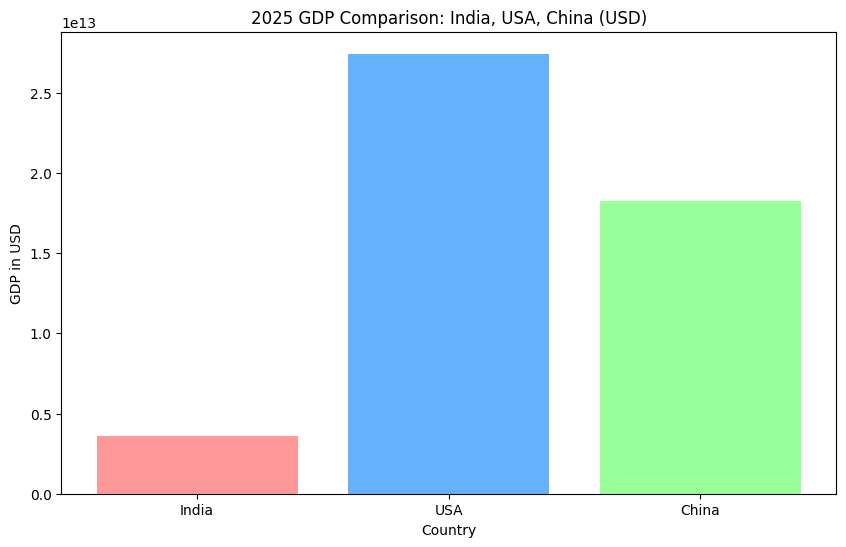

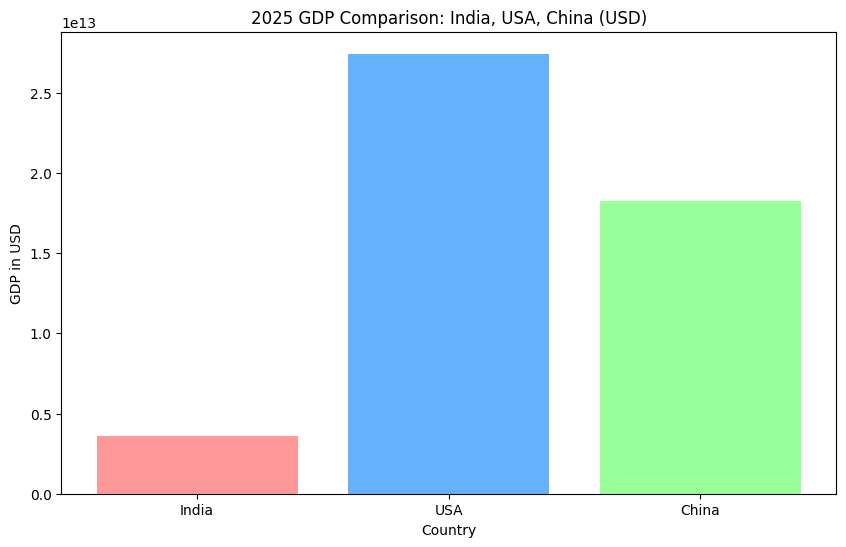

In [10]:
# =========================
# Invoke Graph
# =========================
config = RunnableConfig(
    recursion_limit=10,
    configurable={"thread_id": str(uuid.uuid4())}
)

inputs = {
    "messages": [
        HumanMessage(
            content="do a reserach on gdps of india, usa, and china for the year 2025 & then compare them using a bar chart"
        )
    ]
}

result = app.invoke(inputs, config=config)
result


## 2nd Example: 

In [13]:
inputs = {
    "messages": [
        HumanMessage(
            content="Compare prices of iPhone 15 on Amazon, Flipkart, Meesho & then plot a  bar chart for the same"
        )
    ]
}

result = app.invoke(inputs, config=config)
result


APIStatusError: Error code: 413 - {'error': {'message': 'Request too large for model `qwen/qwen3-32b` in organization `org_01kqs9xjb0f7sswnbq1nmyh9np` service tier `on_demand` on tokens per minute (TPM): Limit 6000, Requested 7552, please reduce your message size and try again. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}

In [15]:
inputs = {
    "messages": [
        HumanMessage(
            content="Compare prices of all versions of iPhone and there launch dates"
        )
    ]
}

result = app.invoke(inputs, config=config)
result


APIStatusError: Error code: 413 - {'error': {'message': 'Request too large for model `qwen/qwen3-32b` in organization `org_01kqs9xjb0f7sswnbq1nmyh9np` service tier `on_demand` on tokens per minute (TPM): Limit 6000, Requested 6724, please reduce your message size and try again. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}